In [ ]:
# from ultralytics import YOLO

# # Load the latest YOLO26n model (nano version for speed)
# model = YOLO("yolo26n.pt")

# # Run inference on an image from a URL
# results = model("https://ultralytics.com/images/bus.jpg", save=True)

# # Display the results with bounding boxes
# results[0].show()

In [ ]:
# results[0].boxes

In [ ]:
# boxes = results[0].boxes
# print(boxes.cls)   # class indices
# print(boxes.conf)  # confidence scores
# print(boxes.xyxy)  # bounding box coordinates (x1, y1, x2, y2)

In [ ]:
# names = model.names           # dict like {0: 'person', 1: 'bicycle', ...}
# for cls_id, conf in zip(boxes.cls, boxes.conf):
#     print(f"{names[int(cls_id)]}: {conf:.2%}")

In [ ]:
# boxes = results[0].boxes
# mask = boxes.conf > 0.7   # keep only high-confidence detections
# filtered_classes = boxes.cls[mask]
# filtered_boxes = boxes.xyxy[mask]
# print(f"Kept {mask.sum().item()} of {len(boxes)} detections")

In [ ]:
# # Track objects in a video file or webcam (source=0)
# # 'show=True' displays the video with bounding boxes and unique IDs
# # results = model.track(source="https://ultralytics.com/images/bus.jpg", show=True)

# results = model.track(source=0, show=True)

# # Access the unique tracking IDs from the results
# if results[0].boxes.id is not None:
#     print(f"Detected Track IDs: {results[0].boxes.id.cpu().numpy()}")

# Object detection with YOLO26

**Audience.** AI students and engineers who have worked through the classification notebooks (`yolo-v0`, `yolo-v1`, `test-yolo`) and now want the *original* YOLO task: object detection.

**Why this is a separate notebook.** Detection is **not** classification with extra steps. The dataset format, the loss, the output, the metrics, the deployment story — all different. Skipping these differences is the #1 reason people get stuck.

**What you will learn:**
1. The mental model: detection vs. classification vs. segmentation.
2. What a detector outputs — bounding boxes, classes, confidences, IoU.
3. How YOLO does detection internally — grids, anchor-free heads, end-to-end NMS-free in YOLO26.
4. Inference on the pretrained COCO model in one line, then a deep dive into the `Results` object.
5. The YOLO **detection** dataset format (`images/` + `labels/` + `data.yaml`) and how it differs from the classification format.
6. Training a custom detector on `coco8` (Ultralytics' built-in 8-image demo).
7. Detection metrics — mAP, IoU, precision, recall — explained from first principles.
8. NMS-free vs. traditional inference in YOLO26 (`end2end=True/False`).
9. How to label your own data and a roadmap to ship.

...

> **About our RPS data.** The Rock-Paper-Scissors dataset only has class labels (folder-based) — no bounding boxes. So in this notebook we'll use:
> - Pretrained **`yolo26n.pt`** (trained on COCO, 80 classes) for inference demos on any image.
> - **`coco8.yaml`** — the official 8-image COCO subset that ships with Ultralytics — for the training demo.
> If you want a custom RPS *detector*, the labelling section at the end shows you how to add bounding boxes to your existing images.


## 1. Detection vs. classification vs. segmentation

All three are computer-vision tasks, but they answer different questions:

| task                         | question                                                         | output                                                |
|------------------------------|------------------------------------------------------------------|-------------------------------------------------------|
| **Image classification**     | *What is in this image?* (one answer for the whole image)         | one class label + confidence                          |
| **Object detection**         | *What objects are in this image, and where are they?*             | list of `(class, confidence, bounding_box)` per object|
| **Instance segmentation**    | *What objects are here, where, and which exact pixels are theirs?*| list of `(class, confidence, polygon_mask)` per object|

**Key shift in mindset.** Classification gives **one** answer; detection gives **a list of any length** (including zero). Your output shape, your metrics, and your evaluation logic must accommodate that.

Example of the same dog-on-a-couch image, three different tasks:

- **Classification.** `dog (0.97)`
- **Detection.** `[ (dog, 0.97, bbox=(120, 80, 410, 360)), (couch, 0.84, bbox=(0, 50, 600, 400)) ]`
- **Segmentation.** Same as detection, but `bbox` is replaced by a per-pixel mask outlining the dog and couch.


## 2. The output of a detector — bounding boxes, IoU, NMS

### 2.1 Bounding box formats

A bounding box is four numbers, but there are *three* common conventions for what those four numbers mean. Mixing them up is a classic source of bugs.

| format               | meaning                                       | example for a 100×100 box at top-left = (50, 60) |
|----------------------|-----------------------------------------------|---------------------------------------------------|
| `xyxy` (corners)     | `(x_min, y_min, x_max, y_max)`                | `(50, 60, 150, 160)`                              |
| `xywh` (top-left+wh) | `(x_min, y_min, width, height)`               | `(50, 60, 100, 100)`                              |
| `cxcywh` (center+wh) | `(center_x, center_y, width, height)`         | `(100, 110, 100, 100)`                            |

**Then there is the absolute vs. normalized distinction:**
- **Absolute (pixels).** The numbers are pixel positions in the original image.
- **Normalized (`[0, 1]`).** The numbers are divided by image width/height so they're scale-invariant.

**YOLO uses `cxcywh` *normalized* for storage** (label files), but `Results.boxes.xyxy` returns absolute pixels by default — convenient for drawing.

### 2.2 IoU — Intersection over Union

IoU measures how well two boxes overlap:

```
          area(box_A ∩ box_B)
IoU  =  ────────────────────
          area(box_A ∪ box_B)
```

IoU = 0 means no overlap; IoU = 1 means perfectly aligned. The convention for "a detection is correct" is **IoU ≥ 0.5** between predicted and ground-truth box (with matching class).

### 2.3 NMS — Non-Maximum Suppression (the *traditional* way)

Detectors typically produce many overlapping candidates for the same object. **NMS** is the post-processing step that, for each class, keeps the highest-confidence box and discards any other box whose IoU with it exceeds a threshold (commonly 0.7).

**YOLO26's big simplification.** The default head is *one-to-one*: each ground-truth object is matched to exactly one prediction during training. At inference time this means **no NMS is needed** — the model already produces a single box per object. Faster, simpler, deployable as one graph. We'll revisit this in section 9.


## 3. How YOLO does detection internally

Skip this section if you only care about using YOLO; come back when you start customising it.

### 3.1 The grid
Every YOLO since v1 divides the image into a grid. Each grid cell is responsible for predicting objects whose center falls in that cell. With multiple feature scales (the *neck*), you get grids at different resolutions — small grids predict large objects, large grids predict small objects.

### 3.2 Anchors → anchor-free
- **YOLOv1–v5** used **anchor boxes**: hand-picked box shapes that the network refined. Worked well but added a hyperparameter (the anchors) and made transfer to new datasets fragile.
- **YOLOv8 onwards (including YOLO26)** are **anchor-free**: the network directly regresses each object's box from the grid cell. Fewer hyperparameters, easier to train.

### 3.3 Decoupled head
The classification branch and the box-regression branch share early features but are split before the final layer. This is empirically more accurate than a coupled head.

### 3.4 What's new in YOLO26 detection
- **DFL removed.** Distribution Focal Loss is gone, simplifying the graph and making ONNX/TFLite exports cleaner.
- **End-to-end NMS-free head.** The default *one-to-one* head produces final predictions directly. You can fall back to a *one-to-many* head with `end2end=False` if you want the small accuracy boost from traditional NMS.
- **STAL** (Small-Target-Aware Label assignment) addresses the famous YOLO weak spot on tiny objects.
- **ProgLoss** progressively re-weights the box vs. classification loss as training proceeds.
- **MuSGD optimizer** (SGD + Muon hybrid) gives more stable training, especially for small datasets.


## 4. Pretrained YOLO26 detection models

These all ship pretrained on **COCO** (80 classes — person, car, dog, chair, etc.). You can either use them directly for those 80 classes, or fine-tune them on your own classes.

| variant      | mAP@50-95 (COCO val) | size (MB) | when to pick it                                |
|--------------|----------------------|-----------|------------------------------------------------|
| `yolo26n`    | ~40.1                | ~5        | edge / mobile / Raspberry Pi                   |
| `yolo26s`    | ~47.8                | ~19       | balanced default for prototypes                |
| `yolo26m`    | ~52.5                | ~42       | server-side production                         |
| `yolo26l`    | ~54.3                | ~51       | accuracy-sensitive workloads                   |
| `yolo26x`    | ~56.8                | ~113      | benchmarks, batch processing, no latency limit |

Special variants worth knowing about:
- `yolo26n-p2.yaml` — extra detection head for **small objects**.
- `yolo26n-p6.yaml` — extra head for **large input images** (e.g. 1280px or 1536px).
- `yolo26-cls`, `yolo26-seg`, `yolo26-pose`, `yolo26-obb` — different tasks, same backbone.
- **YOLOE-26** — open-vocabulary YOLO26 (text-promptable detection without class labels).


## 5. Setup


In [1]:
# Run once per environment
# uv add ultralytics

import ultralytics
from ultralytics import YOLO

ultralytics.checks()

Ultralytics 8.4.46 🚀 Python-3.11.14 torch-2.2.2 CPU (Intel Core i7-9750H 2.60GHz)
Setup complete ✅ (12 CPUs, 16.0 GB RAM, 194.9/465.6 GB disk)


## 6. Inference on the pretrained COCO model — the easy win

Before any training, just *use* a pretrained YOLO26 detector. It already knows 80 classes including people, cars, dogs, bicycles, traffic lights, etc.

On first call, Ultralytics auto-downloads `yolo26n.pt` (~5 MB) and a sample image (`bus.jpg`).


In [2]:
model = YOLO('yolo26n.pt')      # COCO-pretrained, 80 classes

# Predict on Ultralytics' built-in sample image
results = model('https://ultralytics.com/images/bus.jpg', verbose=False, save=True)
r = results[0]

print(f'Found {len(r.boxes)} objects')
for box in r.boxes:
    cls_id = int(box.cls)
    conf   = float(box.conf)
    xyxy   = box.xyxy[0].tolist()    # [x1, y1, x2, y2] in absolute pixels
    print(f'  {r.names[cls_id]:<12} conf={conf:.2f}  bbox={[round(v,1) for v in xyxy]}')

Results saved to /Users/mac/Desktop/Apr 2026/AI/AI-Afternoon/dl-project/runs/detect/predict
Found 5 objects
  bus          conf=0.92  bbox=[0.0, 229.4, 806.1, 757.1]
  person       conf=0.91  bbox=[222.5, 404.9, 345.4, 861.6]
  person       conf=0.91  bbox=[47.7, 399.3, 239.3, 903.0]
  person       conf=0.87  bbox=[670.7, 391.5, 809.8, 879.0]
  person       conf=0.53  bbox=[0.1, 556.7, 60.0, 870.1]


### 6.1 Visualise the annotated result

`r.plot()` returns a numpy image with boxes + labels burnt in (BGR — OpenCV convention). Convert to RGB for matplotlib.


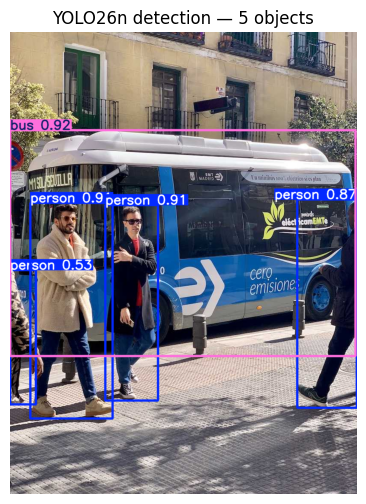

In [3]:
import matplotlib.pyplot as plt

annotated = r.plot()              # BGR numpy array with boxes drawn
annotated_rgb = annotated[..., ::-1]    # BGR -> RGB

plt.figure(figsize=(9, 6))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title(f'YOLO26n detection — {len(r.boxes)} objects')
plt.show()

## 7. Anatomy of the `Results` object for detection

The same `Results` class used in classification carries different attributes for detection. The most useful ones:

| attribute              | what it is                                                                  |
|------------------------|-----------------------------------------------------------------------------|
| `r.boxes`              | a `Boxes` object — vectorised access to all detections in this image       |
| `r.boxes.xyxy`         | tensor `(N, 4)` — `[x1, y1, x2, y2]` in absolute pixels                    |
| `r.boxes.xywh`         | tensor `(N, 4)` — center-x, center-y, width, height in pixels              |
| `r.boxes.xyxyn` / `xywhn` | the same in normalized `[0, 1]` coordinates                              |
| `r.boxes.cls`          | tensor `(N,)` — class indices                                              |
| `r.boxes.conf`         | tensor `(N,)` — confidence per detection                                   |
| `r.names`              | dict `{idx: 'person', ...}`                                                |
| `r.orig_img`           | original image as numpy (BGR)                                              |
| `r.plot()`             | annotated numpy image (BGR)                                                |
| `r.save(...)`          | save annotated image directly                                              |
| `r.save_txt(...)`      | save detections in YOLO label format — perfect for re-training             |

Note that the **box objects are tensors**, so vectorised filtering is one-liner-friendly.


### 7.1 Filter by class and confidence


In [4]:
# Keep only 'person' detections with confidence > 0.7
PERSON_CLASS_ID = 0       # in COCO, 'person' is class 0

boxes = r.boxes
keep = (boxes.cls == PERSON_CLASS_ID) & (boxes.conf > 0.7)

person_boxes = boxes.xyxy[keep]
person_conf  = boxes.conf[keep]

print(f'kept {len(person_boxes)} persons of {len(boxes)} total detections')
for b, c in zip(person_boxes.tolist(), person_conf.tolist()):
    print(f'  conf={c:.2f}  bbox={[round(v,1) for v in b]}')

kept 3 persons of 5 total detections
  conf=0.91  bbox=[222.5, 404.9, 345.4, 861.6]
  conf=0.91  bbox=[47.7, 399.3, 239.3, 903.0]
  conf=0.87  bbox=[670.7, 391.5, 809.8, 879.0]


## 8. Predicting on a folder, video, or webcam

The same `model(source)` call accepts almost any image or video source. Useful options:

| source                  | example                                              |
|-------------------------|------------------------------------------------------|
| single image            | `model('image.jpg')`                                 |
| list of images          | `model(['a.jpg', 'b.jpg'])`                          |
| folder                  | `model('path/to/folder/')`                           |
| URL                     | `model('https://example.com/img.jpg')`               |
| video file              | `model('video.mp4')` — yields per-frame results      |
| webcam                  | `model(0)` — device index, runs until interrupted    |
| RTSP / YouTube stream   | `model('rtsp://...')` / `model('https://youtube...')`|

Useful predict-time arguments:

| arg                | default | meaning                                                                         |
|--------------------|---------|---------------------------------------------------------------------------------|
| `conf`             | 0.25    | minimum confidence to keep a box                                                |
| `iou`              | 0.7     | IoU threshold for NMS (only used when `end2end=False`)                          |
| `imgsz`            | 640     | inference resolution; multiples of 32                                           |
| `classes`          | None    | filter to a list of class ids, e.g. `classes=[0, 2]` for persons + cars         |
| `device`           | None    | `'cpu'`, `0`, `[0,1,2]` for multi-GPU                                           |
| `save`             | False   | save annotated image/video to disk under `runs/detect/predict/`                 |
| `stream`           | False   | for video: yield per-frame instead of buffering all frames in memory            |
| `end2end`          | True    | YOLO26: NMS-free one-to-one head. Set False for traditional NMS-based head.     |


### 8.1 Folder example with class filter


In [ ]:
# Detect only persons + dogs, only above 0.5 confidence, on a folder
# results = model('path/to/folder', conf=0.5, classes=[0, 16])    # 0=person, 16=dog
# for r in results:
#     print(r.path, '-', len(r.boxes), 'objects')

# (commented out so the cell runs without a real folder)

### 8.2 Video / webcam template

**Don't run these cells without an actual source.** They're here as a reference template.


In [ ]:
# # Video file → save annotated video to disk
# model.predict(source='input.mp4', save=True, conf=0.4)
# # Output goes to runs/detect/predict/input.avi

# # Webcam → display in real time (only works in a windowed environment)
# for r in model.predict(source=0, stream=True, conf=0.4):
#     # r is one frame's results; do something with r.boxes here
#     pass

## 9. The dataset format for **detection** (very different from classification)

This is the part that catches everyone. Make a mental note of the two layouts side by side:

### Classification format (what `yolo-cls` uses)
```
rps_data/
├── train/
│   ├── paper/        *.png      ← class is implicit from folder name
│   ├── rock/         *.png
│   └── scissors/     *.png
└── val/  ...
```

### Detection format (what `yolo` uses)
```
my_detection_data/
├── images/
│   ├── train/
│   │   ├── img001.jpg
│   │   └── img002.jpg
│   └── val/
│       ├── img003.jpg
│       └── img004.jpg
├── labels/                       ← parallel structure to images/
│   ├── train/
│   │   ├── img001.txt            ← one label file per image, same basename
│   │   └── img002.txt
│   └── val/
│       ├── img003.txt
│       └── img004.txt
└── data.yaml                     ← describes classes + paths
```

### Inside `img001.txt` — one line per object

```
0 0.504 0.612 0.211 0.358
1 0.310 0.205 0.105 0.180
```

Each line is:

```
<class_id> <center_x> <center_y> <width> <height>
```

All four box numbers are **normalized to `[0, 1]`** (divided by image width/height). Class IDs are integers starting from 0. An empty `.txt` (or no `.txt` at all) means "no objects in this image" — perfectly valid.

### `data.yaml` — the index file

```yaml
path: /absolute/or/relative/path/to/my_detection_data
train: images/train
val:   images/val
test:  images/test           # optional

names:
  0: paper
  1: rock
  2: scissors
```

**This is the file you pass to `data=` in `model.train()`.** The training loop uses it to find images, find labels (by replacing `images/` with `labels/` in the path), and look up class names.


## 10. Training a custom detector — minimal demo on `coco8`

**`coco8`** is Ultralytics' official 8-image subset of COCO. It auto-downloads on first use, fits in seconds of training time, and is perfect for verifying your install is correct.

It's *not* enough to learn anything useful — but the exact same code scales to a full custom dataset. Just point `data=` at your own `.yaml`.


In [ ]:
# Fine-tune yolo26n on coco8 (auto-downloads ~7 MB on first call)
# Tiny number of epochs because this is a smoke test, not a real run.

model = YOLO('yolo26n.pt')

# Uncomment to actually train (takes ~30 seconds on a CPU):
# results = model.train(
#     data    = 'coco8.yaml',
#     epochs  = 3,                  # real runs use 100-300
#     imgsz   = 640,
#     batch   = 8,
#     name    = 'coco8_demo',
#     project = 'runs/detect',
#     plots   = True,
# )


### 10.1 The training arguments that matter for detection

Most are the same as classification (see `yolo-01-classification-deep-dive.ipynb`). The detection-specific ones:

| arg              | default | what it does                                                                          |
|------------------|---------|----------------------------------------------------------------------------------------|
| `imgsz`          | 640     | larger = more accurate on small objects, slower. Use 1280 for high-resolution datasets.|
| `box`            | 7.5     | weight on the box-regression loss term                                                |
| `cls`            | 0.5     | weight on the classification loss term                                                |
| `dfl`            | 1.5     | (legacy) DFL loss weight; ignored in YOLO26 (DFL is removed)                          |
| `mosaic`         | 1.0     | probability of mosaic augmentation (combines 4 images into one); set 0 to disable     |
| `mixup`          | 0.0     | mixup augmentation; usually only helpful at large dataset scale                       |
| `copy_paste`     | 0.0     | copy-paste augmentation for instance segmentation; usually 0 for detection            |

**Outputs land in** `runs/detect/<name>/`. Same files as classification (`results.png`, `confusion_matrix.png`, `weights/best.pt`) plus detection-specific plots (`val_batch0_pred.jpg` shows boxes drawn on val images).


## 11. Detection metrics — mAP, IoU, precision, recall

Accuracy doesn't make sense in detection (you can't have one number when each image has a *list* of predictions). The standard metric is **mAP**.

### Building blocks

| term            | definition                                                                                                       |
|-----------------|-------------------------------------------------------------------------------------------------------------------|
| **True positive (TP)**   | predicted box matches a ground-truth box (same class, IoU ≥ threshold)                                  |
| **False positive (FP)**  | predicted box doesn't match any ground-truth box, or duplicates a TP                                    |
| **False negative (FN)**  | a ground-truth object that no prediction matched                                                         |
| **Precision**            | TP / (TP + FP) — "of the boxes I predicted, how many were correct?"                                    |
| **Recall**               | TP / (TP + FN) — "of the objects that exist, how many did I find?"                                     |

### From precision/recall to mAP

1. Sort all predictions by confidence (high → low).
2. Walk down the list. At each point, compute current precision and recall.
3. Plot precision vs. recall — the **PR curve**.
4. Area under the PR curve = **AP** (average precision) for that class.
5. Average AP over all classes = **mAP**.

### The two mAP variants you'll see in YOLO output

| metric           | meaning                                                                                                |
|------------------|---------------------------------------------------------------------------------------------------------|
| **mAP@0.5**      | mAP using IoU threshold = 0.5. The classic, more lenient COCO metric.                                  |
| **mAP@0.5–0.95** | average of mAP at IoU = 0.5, 0.55, 0.60, ..., 0.95. The strict COCO primary metric. **Use this one.**  |

Higher is always better. State-of-the-art on COCO is in the high 50s.


### 11.1 Reading metrics in code


In [ ]:
# After training (or loading a trained model), validate to get metrics.
# Below assumes you've trained on coco8 and have a checkpoint; adapt path as needed.

# m = YOLO('runs/detect/coco8_demo/weights/best.pt')
# metrics = m.val(data='coco8.yaml')
# print(f'mAP@0.5      : {metrics.box.map50:.4f}')
# print(f'mAP@0.5-0.95 : {metrics.box.map:.4f}')      # primary COCO metric
# print(f'precision    : {metrics.box.mp:.4f}')
# print(f'recall       : {metrics.box.mr:.4f}')


## 12. NMS-free vs. traditional in YOLO26

YOLO26 ships **two heads** in the same checkpoint. You pick which one runs at predict / val / export time via the `end2end` argument.

| head                  | argument        | what it does                                                                          |
|-----------------------|-----------------|-----------------------------------------------------------------------------------------|
| One-to-one (default)  | `end2end=True`  | Each ground-truth object matched to exactly one prediction → **no NMS needed**.        |
| One-to-many           | `end2end=False` | Many candidate predictions → **traditional NMS** filters them. Slightly higher mAP.    |

**When to pick which:**
- **Edge / mobile / web deployment** → `end2end=True`. Cleaner ONNX/TFLite graph, no NMS post-processing in your runtime.
- **Maximum accuracy on a benchmark** → `end2end=False`. Costs you a few ms of post-processing but typically buys ~0.5–1.0 mAP point.

### CLI examples (from the YOLO26 docs)

```bash
# Default — NMS-free, faster deployment
yolo predict model=yolo26n.pt source=image.jpg
yolo export  model=yolo26n.pt format=onnx

# Traditional NMS — small accuracy bump
yolo predict model=yolo26n.pt source=image.jpg end2end=False
yolo export  model=yolo26n.pt format=onnx end2end=False
```


In [ ]:
# Same thing in Python: try both heads and compare counts
model = YOLO('yolo26n.pt')

src = 'https://ultralytics.com/images/bus.jpg'

r_e2e   = model(src, end2end=True,  verbose=False)[0]
r_trad  = model(src, end2end=False, verbose=False)[0]

print(f'NMS-free (one-to-one) : {len(r_e2e.boxes)} objects')
print(f'Traditional + NMS     : {len(r_trad.boxes)} objects')

## 13. Labelling your own data — the practical reality

Bounding boxes don't appear by magic. For a real custom detector you'll spend more time labelling than training.

### Tools (sorted by hassle to set up)

| tool                | hosted? | exports YOLO format? | notes                                                          |
|---------------------|---------|----------------------|----------------------------------------------------------------|
| **Roboflow**        | yes     | yes                  | Easiest start. Free tier covers small projects. Auto-augment.  |
| **CVAT**            | self-hostable | yes            | Open source, very polished, supports videos and segmentation.  |
| **Label Studio**    | self-hostable | yes            | Most flexible. Good for mixed-task projects.                   |
| **LabelMe**         | local    | needs conversion     | Old-school. Outputs JSON, easy to convert.                     |
| **Ultralytics auto-annotate** | local | yes (writes .txt)| Uses a strong pretrained model (or SAM) to pre-label. Saves time.|

### Practical workflow for a custom dataset
1. **Collect** ~100 images per class minimum to get something working; ~1000+ for production.
2. **Label** with one of the tools above. Be consistent: tight boxes, no missed objects.
3. **Export** to YOLO format. Verify a few `.txt` files manually.
4. **Split** into `train/`, `val/`, `test/` (typically 70/20/10 or 80/10/10).
5. **Write `data.yaml`.** Class IDs must match your label files.
6. **Train** — `model.train(data='your_dataset.yaml', epochs=100)`.
7. **Evaluate** mAP on test. If the model is bad, almost always the cause is **labels**, not the model.

### Auto-annotate as a starting point

When you have unlabeled images, Ultralytics provides a one-liner that uses a strong detector + SAM to write initial labels you then correct by hand. This is *much* faster than labelling from scratch.


In [ ]:
# Auto-label a folder of images. Output goes to a 'labels/' dir next to the images.
# Uncomment to run. Requires SAM weights (~350 MB) on first call.

# from ultralytics.data.annotator import auto_annotate
# auto_annotate(
#     data       = 'path/to/your/images',
#     det_model  = 'yolo26x.pt',     # strongest detector for highest-quality starting labels
#     sam_model  = 'sam_b.pt',
# )

## 14. Recap and what's next

You've now seen the full Ultralytics YOLO surface area:

| notebook                                       | task                                          |
|------------------------------------------------|------------------------------------------------|
| `yolo-00-what-is-yolo.ipynb`                   | concepts / history                            |
| `yolo-01-classification-deep-dive.ipynb`       | image classification — every detail           |
| `yolo-v1-improved.ipynb`                       | runnable training (classification)            |
| `test-yolo-improved.ipynb`                     | runnable inference (classification)           |
| **`yolo-02-object-detection.ipynb`** (this)    | **object detection — full workflow**          |

**Three good directions from here, all using the same Ultralytics API:**
1. **Instance segmentation.** Same workflow, replace `yolo26n.pt` with `yolo26n-seg.pt` and add polygon labels.
2. **Pose estimation.** `yolo26n-pose.pt` with keypoint annotations. Used in sports analytics, fitness apps.
3. **Open-vocabulary detection with YOLOE-26.** No training; just text prompts ("red bicycle", "safety helmet"). Game-changer for prototypes.

**Useful reference links:**
- Detection task docs: <https://docs.ultralytics.com/tasks/detect/>
- YOLO26 model card: <https://docs.ultralytics.com/models/yolo26/>
- Configuration reference: <https://docs.ultralytics.com/usage/cfg/>
- Detection dataset formats: <https://docs.ultralytics.com/datasets/detect/>
